In [91]:
import numpy as np
import matplotlib.pyplot as plt



def forcing(x):
    forcing_function = np.sin(2*np.pi*x) + x**2
    return forcing_function

def forcing_extension(f_i):
    extension = -f_i[::-1]
    fE = np.concatenate([f_i, extension])
    return fE


n_pts = 100

x = np.linspace(0, 1, n_pts)
f_i = forcing(x)

x_ext = np.linspace(0, 2, 2 * n_pts)
fE = forcing_extension(f_i)

F = np.fft.fft(fE)



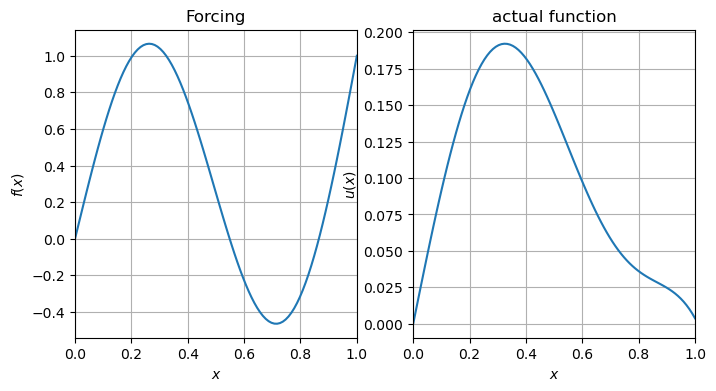

In [92]:


def build_R(m):
    R = np.zeros((2*m, m))

    # Copy interior values (skip first column)
    for i in range(1, m):
        R[i, i] = 1

    # Negative reflected values
    for i in range(1, m):
        R[2*m - i, i] = -1

    return R

def build_D(N, L=1.0):

    # number of Fourier/sine modes
    M = N // 2

    # build diagonal: (1, 1, 2^2, 3^2, ..., (M-1)^2)
    k = np.arange(M)
    diag = np.ones(M)
    diag[2:] = k[2:]**2

    # scale factor
    D_diag = (np.pi / L)**2 * diag

    return D_diag

R = build_R(n_pts)

fE = R @ f_i

F = np.fft.fft(fE) / np.sqrt(len(fE))

A = R.T @ F

D_diag = build_D(len(fE))

B = A / D_diag

C = R @ B

uE = np.fft.ifft(C) * np.sqrt(len(fE))

G = R.T @ uE

plt.subplots(1, 2, figsize=(8, 4))

plt.subplot(1, 2, 1) 
plt.title('Forcing') 
plt.plot(x, f_i)
plt.xlim(0, 1)
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.grid()

plt.subplot(1, 2, 2) 
plt.title('actual function') 
plt.plot(x, G)
plt.xlim(0, 1)
plt.xlabel('$x$')
plt.ylabel('$u(x)$')
plt.grid()


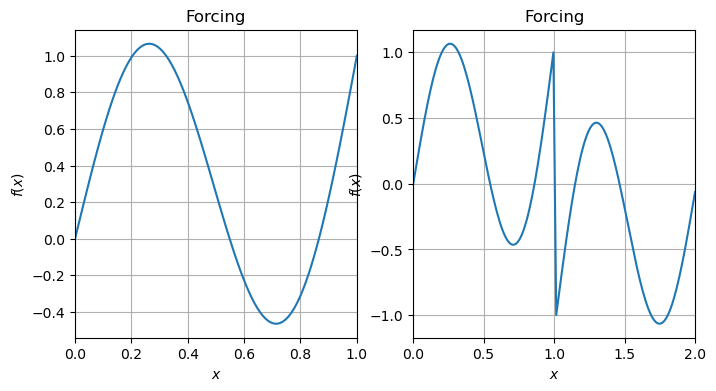

In [93]:
plt.subplots(1, 2, figsize=(8, 4))

plt.subplot(1, 2, 1) 
plt.title('Forcing') 
plt.plot(x, f_i)
plt.xlim(0, 1)
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.grid()

plt.subplot(1, 2, 2) 
plt.title('Forcing') 
plt.plot(x_ext, fE)
plt.xlim(0, 2)
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.grid()